In [ ]:
!pip install torch torchvision timm albumentations torchmetrics


In [ ]:
#Libraries

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models, regularizers, callbacks
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
#Hyper parametrs

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 12
LR = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.5
PATIENCE = 3

In [ ]:
#Split

  (ds_train_full, ds_test), info = tfds.load(
    "cats_vs_dogs",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

train_size = int(0.8 * info.splits["train"].num_examples * 0.8)

ds_train = ds_train_full.take(train_size)
ds_val   = ds_train_full.skip(train_size)


In [ ]:
def preprocess(img, label):
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

def preprocess_train(img, label):
    img, label = preprocess(img, label)
    img = augment(img)
    return img, label

AUTOTUNE = tf.data.AUTOTUNE

ds_train = ds_train.map(preprocess_train, num_parallel_calls=AUTOTUNE)
ds_train = ds_train.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

ds_val = ds_val.map(preprocess, num_parallel_calls=AUTOTUNE)
ds_val = ds_val.batch(BATCH_SIZE).prefetch(AUTOTUNE)

ds_test = ds_test.map(preprocess, num_parallel_calls=AUTOTUNE)
ds_test = ds_test.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [ ]:
#AlexNet architecure

model = models.Sequential([
    layers.Conv2D(96, 11, strides=4, activation="relu",
                  kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
                  input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(3, strides=2),

    layers.Conv2D(256, 5, padding="same", activation="relu",
                  kernel_regularizer=regularizers.l2(WEIGHT_DECAY)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(3, strides=2),

    layers.Conv2D(384, 3, padding="same", activation="relu",
                  kernel_regularizer=regularizers.l2(WEIGHT_DECAY)),
    layers.Conv2D(384, 3, padding="same", activation="relu",
                  kernel_regularizer=regularizers.l2(WEIGHT_DECAY)),
    layers.Conv2D(256, 3, padding="same", activation="relu",
                  kernel_regularizer=regularizers.l2(WEIGHT_DECAY)),
    layers.MaxPooling2D(3, strides=2),

    layers.Flatten(),

    layers.Dense(4096, activation="relu",
                 kernel_regularizer=regularizers.l2(WEIGHT_DECAY)),
    layers.Dropout(DROPOUT),

    layers.Dense(4096, activation="relu",
                 kernel_regularizer=regularizers.l2(WEIGHT_DECAY)),
    layers.Dropout(DROPOUT),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True
)


In [ ]:
history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    callbacks=[early_stop]
)


Epoch 1/12
466/466 ━━━━━━━━━━━━━━━━━━━━ 225s 424ms/step - accuracy: 0.5965 - loss: 1.7031 - val_accuracy: 0.4923 - val_loss: 1.6800
Epoch 2/12
466/466 ━━━━━━━━━━━━━━━━━━━━ 240s 395ms/step - accuracy: 0.7081 - loss: 1.3732 - val_accuracy: 0.7193 - val_loss: 1.2779
Epoch 3/12
466/466 ━━━━━━━━━━━━━━━━━━━━ 194s 395ms/step - accuracy: 0.7541 - loss: 1.1871 - val_accuracy: 0.7720 - val_loss: 1.0952
Epoch 4/12
466/466 ━━━━━━━━━━━━━━━━━━━━ 201s 394ms/step - accuracy: 0.7980 - loss: 1.0259 - val_accuracy: 0.7808 - val_loss: 0.9834
Epoch 5/12
466/466 ━━━━━━━━━━━━━━━━━━━━ 193s 393ms/step - accuracy: 0.8295 - loss: 0.8796 - val_accuracy: 0.8421 - val_loss: 0.8129
Epoch 6/12
466/466 ━━━━━━━━━━━━━━━━━━━━ 193s 392ms/step - accuracy: 0.8470 - loss: 0.7798 - val_accuracy: 0.7540 - val_loss: 0.8886
Epoch 7/12
466/466 ━━━━━━━━━━━━━━━━━━━━ 194s 394ms/step - accuracy: 0.8543 - loss: 0.6981 - val_accuracy: 0.8539 - val_loss: 0.6603
Epoch 8/12
466/466 ━━━━━━━━━━━━━━━━━━━━ 193s 394ms/step - accuracy: 0.8670 -

In [ ]:
test_loss, test_acc = model.evaluate(ds_test)

print("\n===== TEST RESULTS =====")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


146/146 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.8701 - loss: 0.4781

===== TEST RESULTS =====
Test Loss: 0.4785054326057434
Test Accuracy: 0.8693035244941711


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━

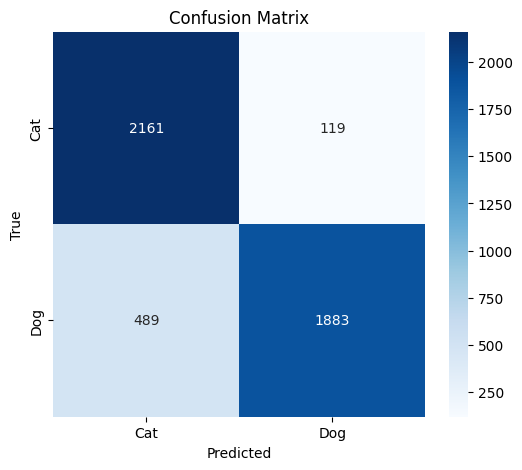


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

         Cat       0.82      0.95      0.88      2280
         Dog       0.94      0.79      0.86      2372

    accuracy                           0.87      4652
   macro avg       0.88      0.87      0.87      4652
weighted avg       0.88      0.87      0.87      4652



In [ ]:
y_true = []
y_pred = []

for images, labels in ds_test:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)
    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Cat","Dog"],
            yticklabels=["Cat","Dog"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_true, y_pred, target_names=["Cat","Dog"]))

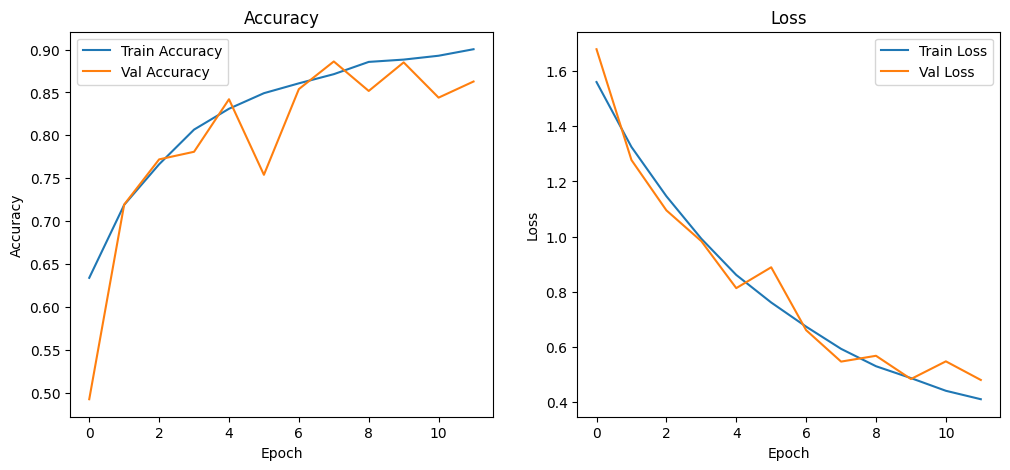

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()